# Depth features v2 — konfound, profil per-gigi, dan fusi dengan DINOv2

Lanjutan dari `depth_anything_v2_inference.ipynb`. Notebook itu sudah menjawab
*"apakah depth-nya bisa dipercaya?"* — jawabannya **ya, dengan syarat**:

| Probe | Hasil | Status |
|---|---|---|
| P1 — korelasi luminance vs depth | \|r\| rata-rata **0.549** | Lolos, **tapi tipis** (ambang 0.6) |
| P4 — stabilitas flip | corr **0.996** | Lolos telak |
| Spekular | rata-rata **19.2%** ROI | Tinggi — perlu di-mask |

Angka P1 = 0.549 itu **hampir menyentuh ambang gagal**. Enam dari 18 foto ada di atas 0.6, dan yang
terburuk (`diastema 1`) mencapai **0.836 dengan 43.6% piksel spekular** — di foto itu depth memang
sebagian besar cuma memantulkan flash. Jadi notebook ini tidak boleh berasumsi depth-nya bersih.
Seluruh Bagian 2 dikhususkan untuk membuktikan fitur mana yang benar-benar mengukur gigi dan mana
yang sebetulnya cuma mengukur kondisi pemotretan.

**Isi notebook:**

1. **Muat ulang depth dari cache** — `.npy` dari notebook 1, tidak perlu inferensi ulang
2. **Fitur v2** — perbaikan bug resize, masking spekular, grid tetap 384x384
3. **Uji konfound** — setiap fitur diadu dengan properti foto murni; yang terkontaminasi dibuang
4. **Profil per-gigi** — deteksi puncak sepanjang lengkung, indeks iregularitas tanpa satuan
5. **Fusi dengan DINOv2** — sweep bobot, dengan bootstrap CI supaya tidak menipu diri sendiri

Jalankan **top-to-bottom**. Bagian 5 butuh unduh DINOv2 (torch.hub) dan inferensi depth untuk
10 anchor AC.

## Bug di notebook 1 yang diperbaiki di sini

**1. Kekasaran bergantung resolusi.** `np.gradient` bekerja per piksel. ROI tiap foto punya ukuran
berbeda (lihat kolom `roi_area` nanti), jadi struktur fisik yang sama menghasilkan gradien per
piksel lebih kecil pada foto beresolusi tinggi. Akibatnya `rough_mean` di notebook 1 sebagian
mengukur **resolusi foto**, bukan kekasaran gigi. Perbaikan: **semua depth di-resize ke 384x384**
sebelum fitur apa pun dihitung.

**2. Piksel spekular ikut terhitung.** Di P1 kita sudah mengecualikan piksel spekular dari
korelasi, tapi `depth_features()` tetap memakainya. Padahal di area itulah depth paling tidak bisa
dipercaya. Perbaikan: **mask spekular**, fitur dihitung hanya pada piksel valid.

**3. `argmax_x` sebagai posisi mentah.** Nilai 0.2 dan 0.8 sama-sama berarti "asimetris", tapi
sebagai angka mentah keduanya berjauhan dan model melihatnya sebagai dua hal berbeda. Perbaikan:
pakai **simpangan dari tengah**, `|argmax/W - 0.5|`.

**4. Klaim "sebaran kedalaman" yang tidak jujur.** `norm01()` memaksa rentang ke [0,1] tiap gambar,
jadi informasi *besarnya* protrusi hancur di langkah itu. Ini **tidak bisa diperbaiki** — output
Depth Anything memang affine-invariant, skalanya tidak ada. Perbaikan: berhenti mengklaimnya.
Semua fitur di sini **tanpa satuan dan tanpa skala**, dan nama-namanya diubah supaya jujur.

In [1]:
# ========= CONFIG =========
CFG = {
    "img_dir":    "Front Teeth drg Laura",
    "depth_dir":  "depth_out",          # cache .npy dari notebook 1
    "out_dir":    "depth_out2",
    "anchor_dir": "ac_references",

    # grid tetap untuk SEMUA perhitungan fitur (perbaikan bug #1)
    "grid":       384,

    # ROI — identik dengan pipeline DINOv2/DINOv3
    "roi_s_thr":  0.30,
    "roi_v_thr":  0.55,
    "roi_pad":    0.10,

    # masking
    "spec_thr":   0.92,      # piksel spekular (perbaikan bug #2)
    "edge_thr":   0.010,     # ambang ABSOLUT magnitudo gradien (perbaikan bug #5)
    "minvar":     1e-6,      # fitur dgn varians di bawah ini dibuang otomatis

    # deteksi puncak (Bagian 4)
    "smooth_frac":  0.03,    # lebar smoothing profil, sebagai fraksi lebar gambar
    "min_dist_frac":0.06,    # jarak minimum antar puncak, fraksi lebar
    "prominence":   0.02,    # prominence minimum (skala 0-1)

    # uji konfound (Bagian 3)
    "confound_thr": 0.60,    # |Spearman| di atas ini -> fitur dianggap terkontaminasi

    # fusi (Bagian 5)
    "dino_encoder": "dinov2_vits14",
    "dino_imgsize": 224,
    "temperature":  0.1,
    "n_boot":       2000,
}
print("CFG:", CFG)

CFG: {'img_dir': 'Front Teeth drg Laura', 'depth_dir': 'depth_out', 'out_dir': 'depth_out2', 'anchor_dir': 'ac_references', 'grid': 384, 'roi_s_thr': 0.3, 'roi_v_thr': 0.55, 'roi_pad': 0.1, 'spec_thr': 0.92, 'edge_thr': 0.01, 'minvar': 1e-06, 'smooth_frac': 0.03, 'min_dist_frac': 0.06, 'prominence': 0.02, 'confound_thr': 0.6, 'dino_encoder': 'dinov2_vits14', 'dino_imgsize': 224, 'temperature': 0.1, 'n_boot': 2000}


## 1. Muat depth dari cache (tanpa inferensi ulang)

In [2]:
import os, glob, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from scipy.stats import spearmanr, pearsonr, skew, kurtosis
from scipy.signal import find_peaks

warnings.filterwarnings("ignore")
try:
    from pillow_heif import register_heif_opener; register_heif_opener()
except Exception:
    pass

os.makedirs(CFG["out_dir"], exist_ok=True)

# --- ROI identik dengan notebook 1 & pipeline DINOv2 ---
def teeth_roi_box(rgb01, dens=0.12):
    s_thr, v_thr, pad = CFG["roi_s_thr"], CFG["roi_v_thr"], CFG["roi_pad"]
    mx = rgb01.max(-1); mn = rgb01.min(-1)
    v = mx; s = np.where(mx > 1e-6, (mx - mn) / (mx + 1e-6), 0.0)
    teeth = (s < s_thr) & (v > v_thr)
    H, W = teeth.shape
    col, row = teeth.mean(0), teeth.mean(1)
    def center_box(fw=0.8, fh=0.6):
        cw, ch = int(W*fw), int(H*fh); x0=(W-cw)//2; y0=(H-ch)//2
        return (x0, y0, x0+cw, y0+ch)
    if col.max() < 1e-3 or row.max() < 1e-3: return center_box()
    cx = np.where(col > dens*col.max())[0]; ry = np.where(row > dens*row.max())[0]
    x0, x1, y0, y1 = int(cx.min()), int(cx.max()), int(ry.min()), int(ry.max())
    bw, bh = x1-x0, y1-y0
    if bw < 0.25*W or bh < 0.15*H: return center_box()
    pw, ph = int(bw*pad), int(bh*pad)
    return (max(0,x0-pw), max(0,y0-ph), min(W,x1+pw), min(H,y1+ph))

def load_rgb(path, max_side=1024):
    im = Image.open(path).convert("RGB")
    if max(im.size) > max_side:
        sc = max_side / max(im.size)
        im = im.resize((int(im.width*sc), int(im.height*sc)), Image.LANCZOS)
    return im

def roi_pil(path):
    im = load_rgb(path)
    return im.crop(teeth_roi_box(np.asarray(im, np.float32)/255.))

EXTS = ("*.jpg","*.jpeg","*.JPG","*.JPEG","*.png","*.PNG","*.heic","*.HEIC")
paths = sorted(set(sum([glob.glob(os.path.join(CFG["img_dir"], e)) for e in EXTS], [])))
names = [os.path.splitext(os.path.basename(p))[0] for p in paths]
print(f"{len(paths)} foto")

# --- muat depth cache ---
DEPTH, RGB, missing = {}, {}, []
for p, n in zip(paths, names):
    f = os.path.join(CFG["depth_dir"], f"{n}.npy")
    im = roi_pil(p)
    RGB[n] = np.asarray(im, np.float32)/255.
    if os.path.exists(f):
        d = np.load(f)
        if d.shape != RGB[n].shape[:2]:
            print(f"  ! shape beda utk {n}: depth{d.shape} vs rgb{RGB[n].shape[:2]} -> pakai apa adanya")
        DEPTH[n] = d
    else:
        missing.append(n)

print(f"depth ter-cache: {len(DEPTH)}/{len(paths)}")
if missing:
    print("HILANG:", missing, "\n-> jalankan ulang notebook 1, atau sel 'inferensi ulang' di bawah.")

18 foto
depth ter-cache: 18/18


In [3]:
# Sel cadangan: jalankan HANYA kalau ada depth yang hilang di atas.
if missing:
    import torch, torch.nn.functional as F
    from transformers import AutoImageProcessor, AutoModelForDepthEstimation
    DEV = torch.device("mps" if torch.backends.mps.is_available()
                       else ("cuda" if torch.cuda.is_available() else "cpu"))
    _mid = "depth-anything/Depth-Anything-V2-Large-hf"
    _proc = AutoImageProcessor.from_pretrained(_mid)
    _mod  = AutoModelForDepthEstimation.from_pretrained(_mid).to(DEV).eval()

    @torch.no_grad()
    def infer_depth(pil):
        inp = _proc(images=pil, return_tensors="pt").to(DEV)
        out = _mod(**inp).predicted_depth
        d = F.interpolate(out.unsqueeze(1), size=pil.size[::-1],
                          mode="bicubic", align_corners=False)[0,0]
        return d.detach().float().cpu().numpy()

    for n in missing:
        p = paths[names.index(n)]
        DEPTH[n] = infer_depth(roi_pil(p))
        np.save(os.path.join(CFG["depth_dir"], f"{n}.npy"), DEPTH[n].astype(np.float32))
        print("  dihitung ulang:", n)
else:
    print("Semua depth tersedia dari cache — tidak perlu inferensi ulang.")

Semua depth tersedia dari cache — tidak perlu inferensi ulang.


## 2. Fitur depth v2

Semua dihitung pada **grid tetap 384x384** dengan **piksel spekular di-mask**.

**Peringatan yang harus terus diingat:** output Depth Anything adalah *relative inverse depth*
dengan skala & offset tak diketahui yang **berbeda tiap foto**. Karena itu tidak ada satu pun fitur
di bawah yang boleh ditafsirkan sebagai besaran fisik. Semuanya mendeskripsikan **bentuk distribusi
dan pola spasial**, bukan "seberapa banyak milimeter".

| Fitur | Arti |
|---|---|
| `spread_iqr`, `spread_std` | Bentuk histogram kedalaman: menyebar rata vs mengelompok |
| `bimodality` | Seberapa terbelah histogramnya — proxy "ada gigi yang jelas menonjol" |
| `rough_mean`, `rough_p90` | Rata-rata & ekor atas magnitudo gradien: banyak/tajamnya tepi |
| `edge_density` | Fraksi piksel bertepi kuat |
| `arch_std`, `arch_range` | Variasi profil kedalaman sepanjang sumbu horizontal (lengkung) |
| `arch_curvature` | Seberapa melengkung profil itu — arch normal harus cembung |
| `asim_LR`, `asim_TB` | Selisih kedalaman kiri-kanan / atas-bawah |
| `center_dev` | Simpangan titik terdekat dari garis tengah |
| `valid_frac` | Fraksi piksel non-spekular (indikator kualitas, bukan fitur klinis) |

In [4]:
G = CFG["grid"]

def _resize(a, size=G, order="bilinear"):
    """Resize array 2D ke grid tetap (perbaikan bug #1)."""
    im = Image.fromarray(a.astype(np.float32), mode="F")
    return np.asarray(im.resize((size, size),
                      Image.BILINEAR if order == "bilinear" else Image.NEAREST), np.float32)

def robust01(d, mask=None):
    """Normalisasi persentil 1-99 pada piksel valid. Tanpa satuan (memang begitu adanya)."""
    v = d[mask] if mask is not None and mask.any() else d
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((d - lo) / (hi - lo + 1e-8), 0, 1)

def prep(name):
    """-> (depth 384x384 ternormalisasi, mask valid 384x384, rgb 384x384)."""
    rgb, d = RGB[name], DEPTH[name]
    rgb_r = np.stack([_resize(rgb[..., c]) for c in range(3)], -1)
    d_r   = _resize(d)
    spec  = rgb_r.max(-1) > CFG["spec_thr"]
    mask  = ~spec
    return robust01(d_r, mask), mask, rgb_r

def depth_features_v2(dn, mask):
    f = {}
    v = dn[mask]
    if v.size < 100:                       # ROI hampir seluruhnya spekular
        v, mask = dn.ravel(), np.ones_like(dn, bool)

    # --- bentuk distribusi ---
    p25, p50, p75 = np.percentile(v, [25, 50, 75])
    f["spread_iqr"] = p75 - p25
    f["spread_std"] = float(v.std())
    # Sarle's bimodality coefficient: BC = (skew^2 + 1) / (kurtosis + 3(n-1)^2/((n-2)(n-3)))
    # BC > 5/9 (~0.556) menandakan distribusi cenderung bimodal.
    nn = len(v)
    g1, g2 = float(skew(v)), float(kurtosis(v, fisher=True))
    corr = 3*(nn-1)**2/max((nn-2)*(nn-3), 1)
    f["bimodality"] = float((g1**2 + 1)/(g2 + corr + 1e-8))

    # --- tekstur / tepi (grid tetap -> sebanding antar foto) ---
    gy, gx = np.gradient(dn)
    gm = np.hypot(gx, gy)
    gv = gm[mask]
    f["rough_mean"]   = float(gv.mean())
    f["rough_p90"]    = float(np.percentile(gv, 90))
    f["edge_density"] = float((gv > CFG["edge_thr"]).mean())   # ambang absolut, bukan persentil

    # --- profil lengkung (rata-rata kolom, hanya piksel valid) ---
    num = (dn * mask).sum(0); den = mask.sum(0) + 1e-8
    cols = num / den
    cols = np.convolve(cols, np.ones(9)/9, mode="same")
    f["arch_std"]   = float(cols.std())
    f["arch_range"] = float(cols.max() - cols.min())
    # kelengkungan: koefisien kuadratik dari fit polinomial derajat 2
    xs = np.linspace(-1, 1, len(cols))
    f["arch_curvature"] = float(np.polyfit(xs, cols, 2)[0])

    # --- asimetri ---
    W = dn.shape[1]; H = dn.shape[0]
    L, R = dn[:, :W//2][mask[:, :W//2]], dn[:, W//2:][mask[:, W//2:]]
    T, B = dn[:H//2][mask[:H//2]], dn[H//2:][mask[H//2:]]
    f["asim_LR"] = float(L.mean() - R.mean()) if L.size and R.size else 0.0
    f["asim_TB"] = float(T.mean() - B.mean()) if T.size and B.size else 0.0
    f["center_dev"] = float(abs(np.argmax(cols)/len(cols) - 0.5))   # perbaikan bug #3

    # --- kualitas ---
    f["valid_frac"] = float(mask.mean())
    return f

PREP = {n: prep(n) for n in DEPTH}
FEAT = pd.DataFrame({n: depth_features_v2(PREP[n][0], PREP[n][1]) for n in DEPTH}).T
FEAT.index.name = "foto"
print(FEAT.round(4).to_string())
FEAT.to_csv(os.path.join(CFG["out_dir"], "features_v2.csv"))

                                                                      spread_iqr  spread_std  bimodality  rough_mean  rough_p90  edge_density  arch_std  arch_range  arch_curvature  asim_LR  asim_TB  center_dev  valid_frac
foto                                                                                                                                                                                                                         
kelas 1 dengan diastema 1                                                 0.3632      0.2574      0.4847      0.0109     0.0212        0.2609    0.2782      0.9783         -0.6335   0.1094  -0.0826      0.2370      0.5642
kelas 1 dengan diastema 2                                                 0.5895      0.3104      0.6831      0.0075     0.0128        0.1535    0.1577      0.5671         -0.5017  -0.0749   0.0310      0.0312      0.8452
kelas 1 normal 1                                                          0.4996      0.2867      0.6256      0.

## 3. Uji konfound — fitur mana yang sebenarnya cuma mengukur kameranya?

Ini bagian paling penting dari notebook ini.

18 foto ini diambil pada tahun berbeda (2022–2025), kemungkinan besar dengan kamera dan
pencahayaan berbeda. **Variasi fotografis bisa dengan mudah melebihi variasi klinis.** Kalau
sebuah fitur berkorelasi kuat dengan properti foto murni, fitur itu memodelkan fotografer,
bukan pasien — dan menambahkannya ke pipeline justru merusak.

Properti foto yang diuji (semuanya **tidak ada hubungannya dengan gigi**):

- `roi_area`, `roi_aspect` — ukuran & rasio crop ROI
- `lum_mean`, `lum_std` — kecerahan & kontras
- `spec_pct` — persentase piksel spekular (proxy kekuatan flash)
- `src_megapixel` — resolusi file asli

Aturan: **|Spearman| > 0.60 terhadap properti mana pun → fitur dibuang.**

Ini ambang yang keras dan sebagian fitur pasti gugur. Itu justru tujuannya.

In [5]:
props = {}
for p, n in zip(paths, names):
    if n not in DEPTH: continue
    rgb = RGB[n]
    H, W = rgb.shape[:2]
    lum = rgb.mean(-1)
    with Image.open(p) as im0:
        mp = (im0.size[0]*im0.size[1])/1e6
    props[n] = {
        "roi_area":      H*W/1e4,
        "roi_aspect":    W/H,
        "lum_mean":      float(lum.mean()),
        "lum_std":       float(lum.std()),
        "spec_pct":      float((rgb.max(-1) > CFG["spec_thr"]).mean()),
        "src_megapixel": mp,
    }
PROP = pd.DataFrame(props).T.loc[FEAT.index]
print(PROP.round(3).to_string())

                                                                      roi_area  roi_aspect  lum_mean  lum_std  spec_pct  src_megapixel
foto                                                                                                                                  
kelas 1 dengan diastema 1                                               15.636       4.155     0.631    0.171     0.436          1.288
kelas 1 dengan diastema 2                                               66.970       1.566     0.554    0.167     0.157          1.119
kelas 1 normal 1                                                        29.857       2.241     0.568    0.107     0.077          2.921
kelas 1 normal 2                                                        34.104       3.021     0.634    0.148     0.105          2.151
kelas 1 normal 3                                                        42.798       2.304     0.557    0.182     0.318          1.781
kelas 1 with crossbite and crowding 1                  

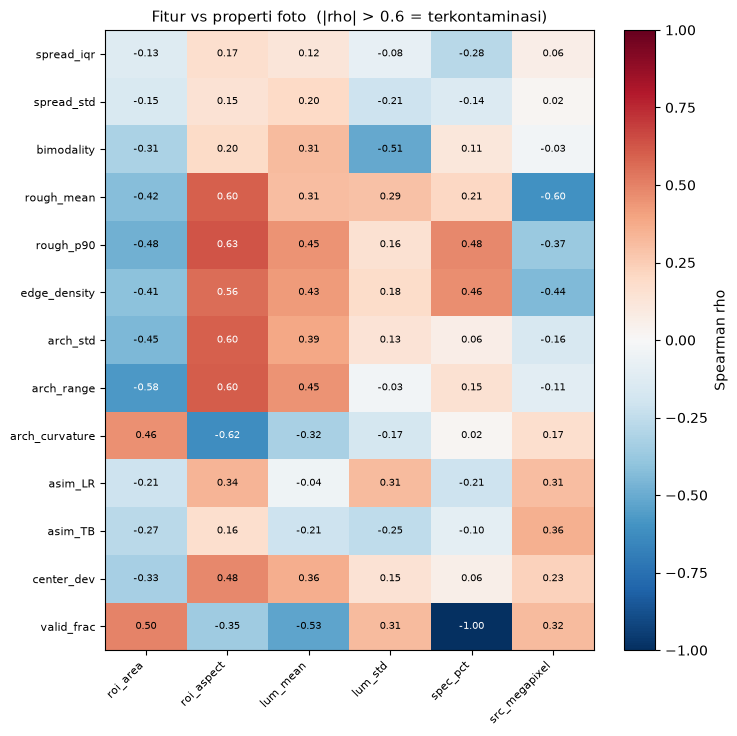


BERSIH  (8): ['spread_iqr', 'spread_std', 'bimodality', 'edge_density', 'arch_std', 'asim_LR', 'asim_TB', 'center_dev']
DIBUANG (5): ['rough_mean', 'rough_p90', 'arch_range', 'arch_curvature', 'valid_frac']
   rough_mean      <- src_megapixel (rho=-0.60)
   rough_p90       <- roi_aspect (rho=+0.63)
   arch_range      <- roi_aspect (rho=+0.60)
   arch_curvature  <- roi_aspect (rho=-0.62)


In [6]:
C = pd.DataFrame(index=FEAT.columns, columns=PROP.columns, dtype=float)
for f in FEAT.columns:
    for q in PROP.columns:
        C.loc[f, q] = spearmanr(FEAT[f].values, PROP[q].values)[0]
C = C.astype(float)

thr = CFG["confound_thr"]
worst = C.abs().max(1)

# Filter #0: fitur nyaris konstan tidak membawa informasi apa pun. Fitur seperti ini
# LOLOS uji konfound secara palsu (tidak ada varians -> tidak bisa berkorelasi dgn apa pun),
# jadi harus dibuang lebih dulu.
VAR = FEAT.var()
FLAT = [f for f in FEAT.columns if VAR[f] < CFG["minvar"] or np.isnan(worst[f])]

CLEAN = [f for f in FEAT.columns
         if f not in FLAT and worst[f] <= thr and f != "valid_frac"]
DIRTY = [f for f in FEAT.columns if f not in CLEAN]

fig, ax = plt.subplots(figsize=(7.5, 0.42*len(C)+2))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(C.shape[1])); ax.set_xticklabels(C.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(C.shape[0])); ax.set_yticklabels(C.index, fontsize=8)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        val = C.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(val) > 0.55 else "black")
plt.colorbar(im, label="Spearman rho")
ax.set_title(f"Fitur vs properti foto  (|rho| > {thr} = terkontaminasi)", fontsize=11)
plt.tight_layout(); plt.show()

print(f"\nBERSIH  ({len(CLEAN)}): {CLEAN}")
print(f"DIBUANG ({len(DIRTY)}): {DIRTY}")
if FLAT: print(f"   (varians ~nol, tidak informatif: {FLAT})")
for f in DIRTY:
    if f == "valid_frac" or f in FLAT: continue
    j = int(np.argmax(np.abs(C.loc[f].values)))
    print(f"   {f:15s} <- {C.columns[j]} (rho={C.loc[f].values[j]:+.2f})")
C.to_csv(os.path.join(CFG["out_dir"], "confound_matrix.csv"))

## 4. Profil per-gigi — indeks iregularitas tanpa satuan

Fitur di Bagian 2 semuanya **global**: mereka tidak tahu ada berapa gigi di foto. Bagian ini satu
langkah lebih dekat ke geometri per gigi, tanpa perlu label apa pun.

**Idenya.** Profil kedalaman rata-rata sepanjang sumbu horizontal membentuk deretan puncak — tiap
puncak kira-kira adalah titik paling menonjol dari satu gigi, tiap lembah adalah sela antar gigi.
Dari deretan puncak itu kita ukur dua hal:

- **`spacing_cv`** = simpangan baku jarak antar-puncak ÷ rata-ratanya. Gigi rapi = jarak seragam →
  CV kecil. Berjejal = jarak tidak beraturan → CV besar.
- **`prom_cv`** = koefisien variasi *prominence* puncak. Gigi sebidang = prominence seragam.
  Ada yang labioversi/palatoversi = prominence sangat bervariasi.

**Kenapa dibagi rata-ratanya?** Ini poin yang kita bahas sebelumnya: dengan membagi rata-rata,
hasilnya jadi **tanpa satuan dan sebanding antar foto** — tidak perlu kalibrasi px→mm, tidak perlu
marker. Gigi menjadi penggarisnya sendiri. Ini semangat yang sama dengan **Little's Irregularity
Index** yang dinormalisasi lebar insisivus, hanya saja dihitung dari profil depth, bukan dari
titik kontak hasil segmentasi.

**Batasnya, supaya jelas:** ini **bukan** deteksi gigi. Puncak yang ditemukan bisa saja pantulan
flash atau sela bibir. Anggap ini proxy termurah; versi yang benar-benar bisa dipertanggungjawabkan
secara klinis tetap butuh segmentasi per gigi + LII sungguhan.

In [7]:
def arch_profile(dn, mask):
    num = (dn*mask).sum(0); den = mask.sum(0) + 1e-8
    cols = num/den
    k = max(3, int(CFG["smooth_frac"]*len(cols)))
    return np.convolve(cols, np.ones(k)/k, mode="same")

def tooth_peaks(prof):
    dist = max(2, int(CFG["min_dist_frac"]*len(prof)))
    pk, props_ = find_peaks(prof, distance=dist, prominence=CFG["prominence"])
    return pk, props_.get("prominences", np.array([]))

def irregularity(prof):
    pk, prom = tooth_peaks(prof)
    out = {"n_peaks": len(pk), "spacing_cv": np.nan, "prom_cv": np.nan, "prom_mean": np.nan}
    if len(pk) >= 3:
        gaps = np.diff(pk).astype(float)
        out["spacing_cv"] = float(gaps.std()/(gaps.mean()+1e-8))
    if len(prom) >= 2:
        out["prom_cv"]   = float(prom.std()/(prom.mean()+1e-8))
        out["prom_mean"] = float(prom.mean())
    return out

PROF = {n: arch_profile(*PREP[n][:2]) for n in DEPTH}
IRR  = pd.DataFrame({n: irregularity(PROF[n]) for n in DEPTH}).T.loc[FEAT.index]
print(IRR.round(3).to_string())
IRR.to_csv(os.path.join(CFG["out_dir"], "irregularity.csv"))

                                                                      n_peaks  spacing_cv  prom_cv  prom_mean
foto                                                                                                         
kelas 1 dengan diastema 1                                                 4.0       0.506    0.877      0.399
kelas 1 dengan diastema 2                                                 3.0       0.542    1.148      0.211
kelas 1 normal 1                                                          5.0       0.081    1.512      0.150
kelas 1 normal 2                                                          7.0       0.355    1.521      0.186
kelas 1 normal 3                                                          5.0       0.464    1.217      0.123
kelas 1 with crossbite and crowding 1                                     3.0       0.067    0.686      0.169
kelas 1 with crowding lower anterior 1                                    4.0       0.416    1.324      0.146
kelas 1 wi

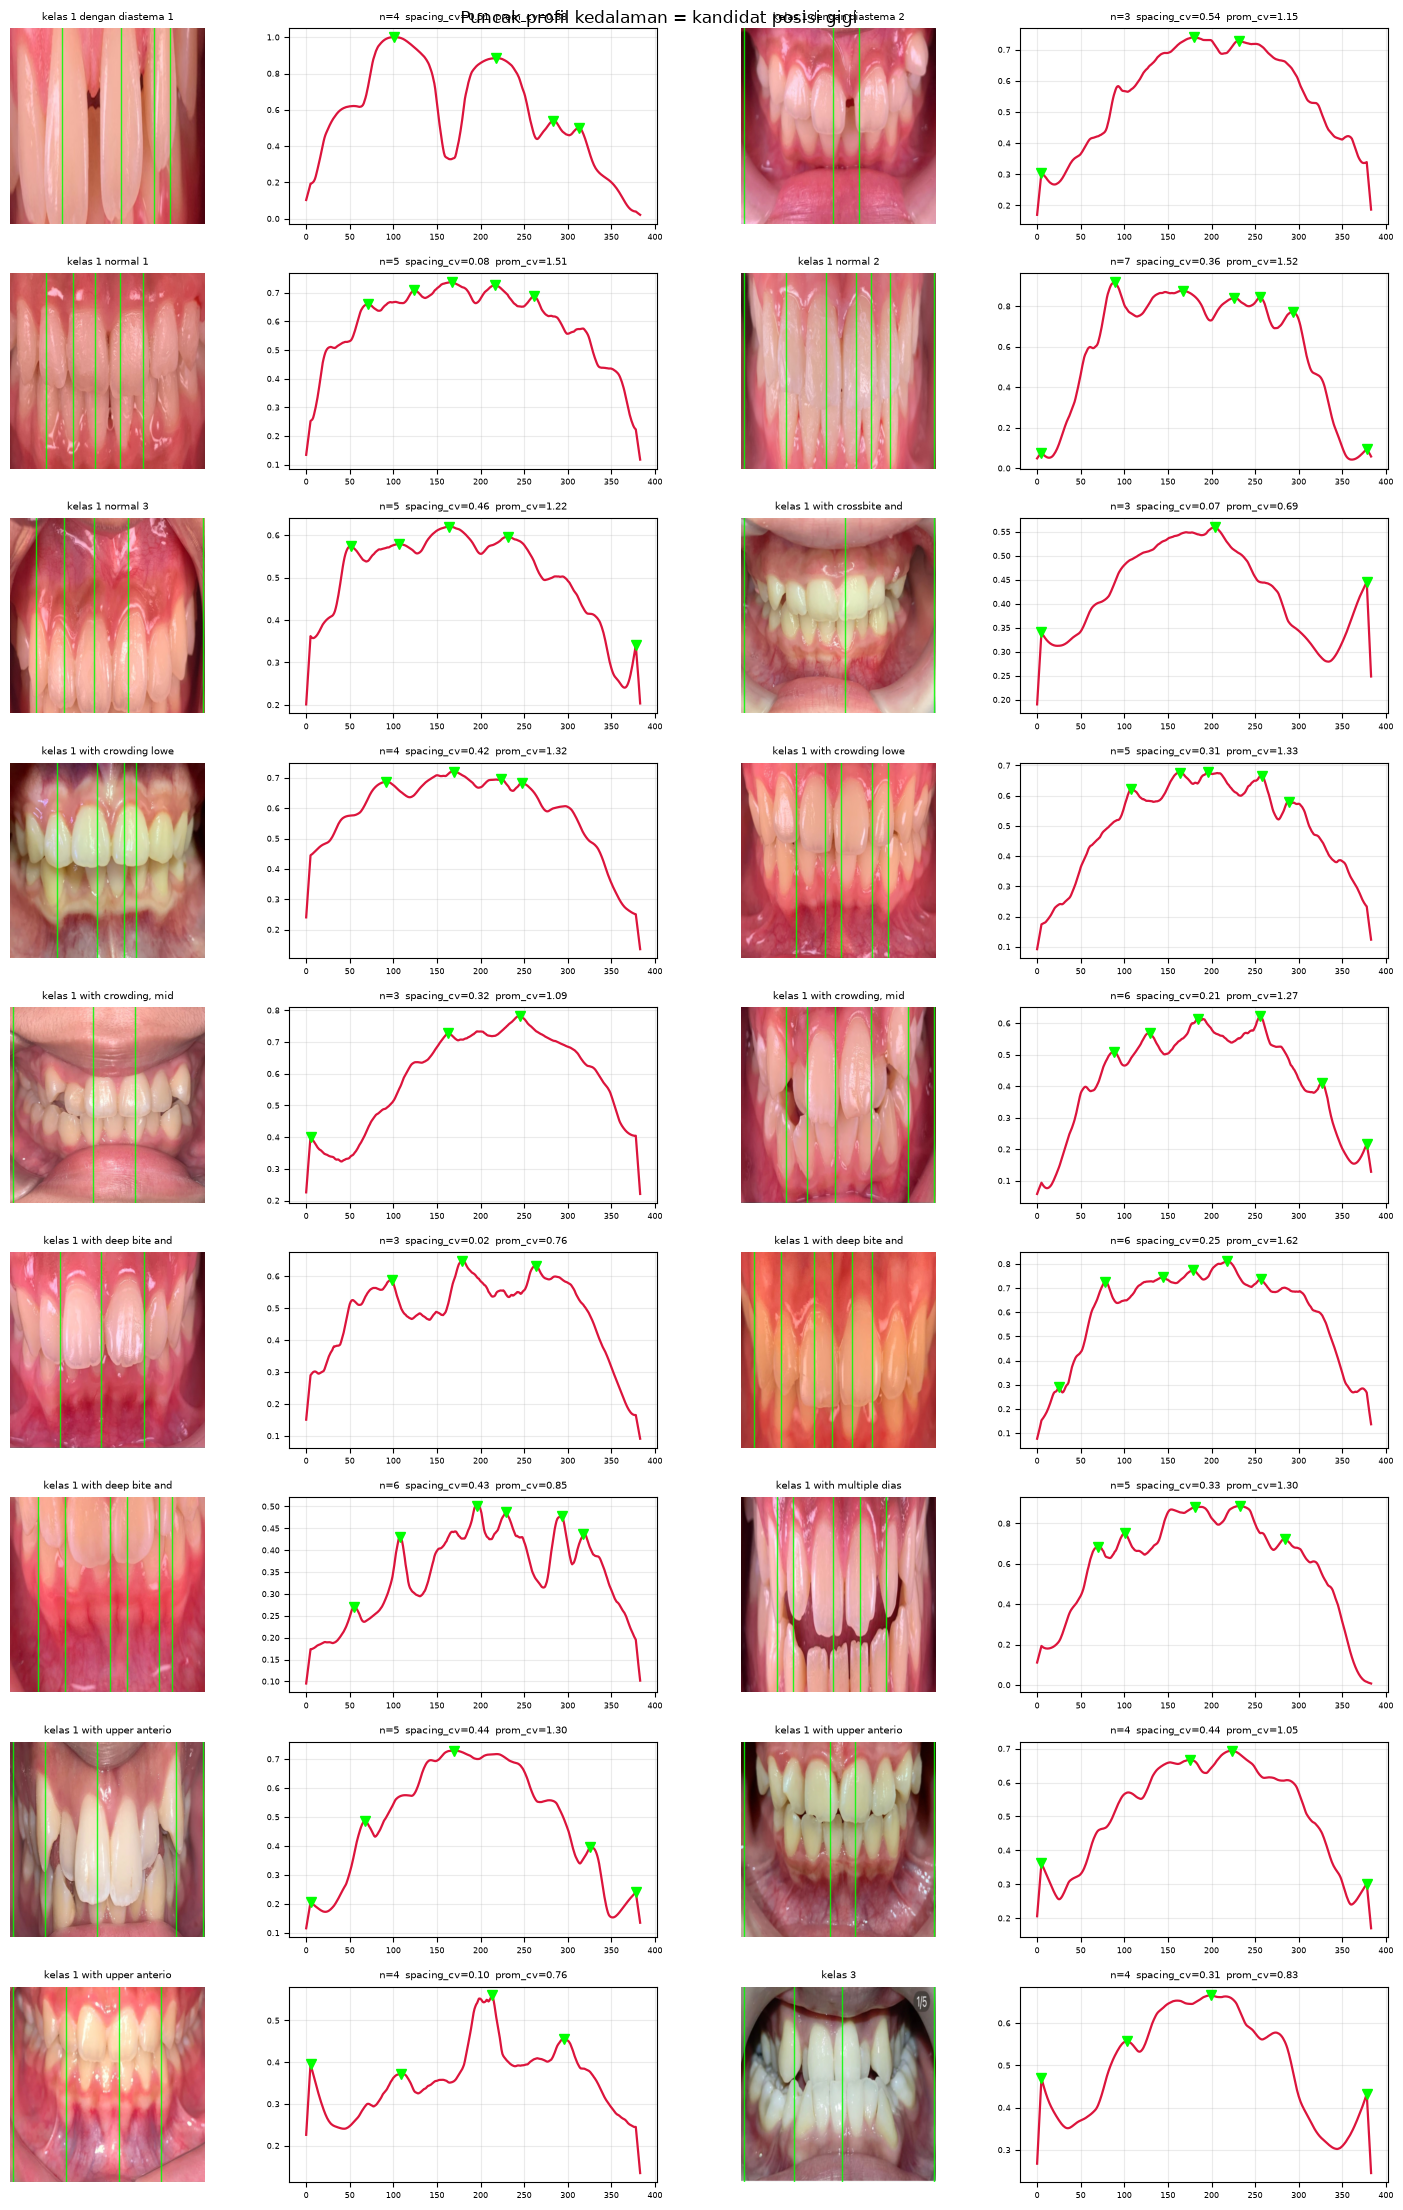

In [8]:
N = len(PROF)
ncol = 2; nrow = int(np.ceil(N/ncol))
fig, axes = plt.subplots(nrow, ncol*2, figsize=(15, 2.5*nrow))
axes = np.atleast_2d(axes)
for i, n in enumerate(FEAT.index):
    rr, cc = divmod(i, ncol)
    a_im, a_pr = axes[rr, cc*2], axes[rr, cc*2+1]
    dn, mask, rgb = PREP[n]
    prof = PROF[n]; pk, prom = tooth_peaks(prof)

    a_im.imshow(rgb); a_im.axis("off"); a_im.set_title(n[:26], fontsize=7)
    for x in pk: a_im.axvline(x, color="lime", lw=1.0, alpha=0.85)

    a_pr.plot(prof, color="crimson", lw=1.6)
    a_pr.plot(pk, prof[pk], "v", color="lime", ms=7)
    sc = IRR.loc[n]
    a_pr.set_title(f"n={int(sc['n_peaks'])}  spacing_cv={sc['spacing_cv']:.2f}  prom_cv={sc['prom_cv']:.2f}",
                   fontsize=7)
    a_pr.tick_params(labelsize=6); a_pr.grid(alpha=0.25)

for j in range(N, nrow*ncol):
    rr, cc = divmod(j, ncol)
    axes[rr, cc*2].axis("off"); axes[rr, cc*2+1].axis("off")
plt.suptitle("Puncak profil kedalaman = kandidat posisi gigi", fontsize=12)
plt.tight_layout(); plt.show()

In [9]:
# Apakah indeks iregularitas sejalan dengan weak-label? (dan apakah ia juga terkonfound?)
ALIAS = {"normal":["normal"], "diastema":["diastema"],
         "crowding":["crowding","croeding"], "crossbite":["crossbite"],
         "protrusion":["protrusion"], "open bite":["open bite"], "deep bite":["deep bite"]}
def labels_of(n):
    ln = n.lower()
    return [k for k,a in ALIAS.items() if any(x in ln for x in a)] or ["lain"]

rows = []
for n in FEAT.index:
    for lab in labels_of(n):
        rows.append({"label": lab, **IRR.loc[n].to_dict()})
L = pd.DataFrame(rows)
print(L.groupby("label")[["spacing_cv","prom_cv","n_peaks"]].agg(["mean","count"]).round(3).to_string())

print("\n--- uji konfound utk indeks iregularitas ---")
for f in ["spacing_cv","prom_cv","n_peaks","prom_mean"]:
    v = IRR[f].astype(float).values
    ok = ~np.isnan(v)
    if ok.sum() < 5:
        print(f"  {f:12s} data kurang"); continue
    best = max(((q, spearmanr(v[ok], PROP[q].values[ok])[0]) for q in PROP.columns),
               key=lambda t: abs(t[1]))
    flag = "TERKONTAMINASI" if abs(best[1]) > CFG["confound_thr"] else "bersih"
    print(f"  {f:12s} paling terkait {best[0]} (rho={best[1]:+.2f}) -> {flag}")

           spacing_cv       prom_cv       n_peaks      
                 mean count    mean count    mean count
label                                                  
crossbite       0.196     3   1.017     3   4.000     3
crowding        0.286     8   1.102     8   4.250     8
deep bite       0.232     3   1.076     3   5.000     3
diastema        0.458     3   1.107     3   4.000     3
lain            0.311     1   0.828     1   4.000     1
normal          0.300     3   1.417     3   5.667     3
open bite       0.326     1   1.297     1   5.000     1
protrusion      0.232     3   1.076     3   5.000     3

--- uji konfound utk indeks iregularitas ---
  spacing_cv   paling terkait lum_std (rho=+0.46) -> bersih
  prom_cv      paling terkait roi_aspect (rho=+0.38) -> bersih
  n_peaks      paling terkait roi_area (rho=-0.66) -> TERKONTAMINASI
  prom_mean    paling terkait lum_mean (rho=+0.33) -> bersih


## 5. Fusi dengan DINOv2 untuk ranking AC

Sekarang kita uji pertanyaan sebenarnya: **apakah menambahkan fitur depth memperbaiki penilaian AC,
atau justru merusaknya?**

Skemanya:

```
vektor gabungan = [ embedding DINOv2 (L2=1) ,  w * fitur depth bersih (L2=1) ]
```

`w = 0` berarti murni DINOv2 (baseline saat ini). Kita sapu `w` dari 0 sampai 1 dan lihat apakah
ada nilai yang mengalahkan baseline.

**Peringatan metodologis yang tidak boleh diabaikan.** Kita cuma punya 18 foto dan label lemah
dari nama file. Menyapu `w` lalu memilih yang terbaik **hampir pasti menemukan perbaikan semu** —
dengan n sekecil ini, selalu ada nilai `w` yang kebetulan cocok dengan noise. Karena itu setiap
titik disertai **bootstrap 95% CI**. Kalau CI-nya bertumpang tindih dengan baseline `w=0`,
maka **tidak ada perbaikan yang bisa diklaim**, sebagus apa pun angka tengahnya.

**Dan soal anchor:** 10 referensi AC adalah **foto hasil pindai gambar cetak**, bukan foto klinis.
Depth Anything pada gambar cetak besar kemungkinan menghasilkan sesuatu yang tidak bermakna
(ia akan "melihat" geometri halaman, bukan geometri gigi). Sel berikutnya menampilkannya supaya
kamu bisa menilai sendiri — **lihat dulu sebelum percaya angka mana pun di bagian ini.**

In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

DEV = torch.device("mps" if torch.backends.mps.is_available()
                   else ("cuda" if torch.cuda.is_available() else "cpu"))
anchor_paths  = sorted(glob.glob(os.path.join(CFG["anchor_dir"], "ac_grade_*.png")))
anchor_grades = list(range(1, len(anchor_paths)+1))
assert len(anchor_paths) == 10, f"harus 10 anchor, dapat {len(anchor_paths)}"

_mid  = "depth-anything/Depth-Anything-V2-Large-hf"
_proc = AutoImageProcessor.from_pretrained(_mid)
_mod  = AutoModelForDepthEstimation.from_pretrained(_mid).to(DEV).eval()

@torch.no_grad()
def infer_depth(pil):
    inp = _proc(images=pil, return_tensors="pt").to(DEV)
    out = _mod(**inp).predicted_depth
    d = F.interpolate(out.unsqueeze(1), size=pil.size[::-1], mode="bicubic",
                      align_corners=False)[0,0]
    return d.detach().float().cpu().numpy()

for p in anchor_paths:
    n = os.path.splitext(os.path.basename(p))[0]
    im = roi_pil(p)
    RGB[n]   = np.asarray(im, np.float32)/255.
    DEPTH[n] = infer_depth(im)
    PREP[n]  = prep(n)
anchor_names = [os.path.splitext(os.path.basename(p))[0] for p in anchor_paths]
print("depth anchor selesai:", len(anchor_names))

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

depth anchor selesai: 10


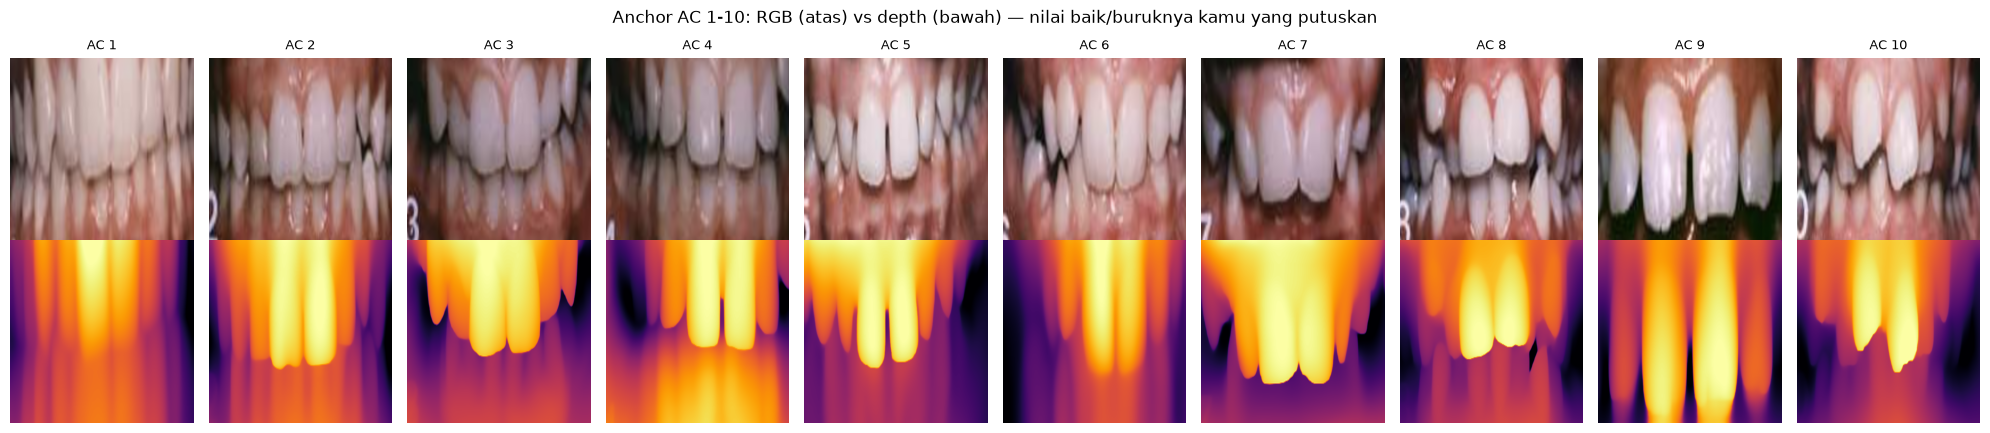

             spread_iqr  spread_std  bimodality  edge_density  arch_std  asim_LR  asim_TB  center_dev  spacing_cv  prom_cv
ac_grade_01       0.279       0.221       0.410         0.108     0.206    0.078    0.097       0.052       0.280    1.189
ac_grade_02       0.411       0.258       0.479         0.137     0.230    0.044    0.164       0.102       0.053    1.123
ac_grade_03       0.439       0.269       0.487         0.068     0.183    0.022    0.205       0.060       0.500    1.041
ac_grade_04       0.368       0.259       0.552         0.121     0.225   -0.237   -0.048       0.055       0.558    0.684
ac_grade_05       0.524       0.294       0.562         0.102     0.223    0.218    0.253       0.143       0.115    0.833
ac_grade_06       0.455       0.273       0.514         0.123     0.247   -0.243    0.183       0.031       0.048    1.151
ac_grade_07       0.586       0.307       0.650         0.086     0.198    0.063    0.295       0.081       0.365    1.394
ac_grade_08     

In [11]:
# LIHAT DULU: apakah depth pada anchor masuk akal atau sampah?
fig, ax = plt.subplots(2, 10, figsize=(20, 4.4))
for k, n in enumerate(anchor_names):
    dn, mask, rgb = PREP[n]
    ax[0,k].imshow(rgb); ax[0,k].axis("off"); ax[0,k].set_title(f"AC {k+1}", fontsize=9)
    ax[1,k].imshow(dn, cmap="inferno"); ax[1,k].axis("off")
plt.suptitle("Anchor AC 1-10: RGB (atas) vs depth (bawah) — nilai baik/buruknya kamu yang putuskan",
             fontsize=12)
plt.tight_layout(); plt.show()

anc_feat = pd.DataFrame({n: depth_features_v2(*PREP[n][:2]) for n in anchor_names}).T
anc_irr  = pd.DataFrame({n: irregularity(arch_profile(*PREP[n][:2])) for n in anchor_names}).T
print(pd.concat([anc_feat[CLEAN], anc_irr[["spacing_cv","prom_cv"]]], axis=1).round(3).to_string())

In [12]:
# --- embedding DINOv2 (persis seperti pipeline yang sudah ada) ---
IMG_SIZE = CFG["dino_imgsize"]
IMAGENET_MEAN = np.array([0.485,0.456,0.406], np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], np.float32)

dmodel = torch.hub.load("facebookresearch/dinov2", CFG["dino_encoder"]).eval().to(DEV)
print("DINOv2 dim:", dmodel.embed_dim)

def load_roi_arr(path, size=IMG_SIZE):
    return np.asarray(roi_pil(path).resize((size,size)), np.float32)/255.

@torch.no_grad()
def dino_embed(arr):
    x = (arr - IMAGENET_MEAN)/IMAGENET_STD
    x = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).float().to(DEV)
    v = dmodel.forward_features(x)["x_norm_clstoken"][0].float().cpu().numpy()
    return v/(np.linalg.norm(v)+1e-8)

E_test = np.stack([dino_embed(load_roi_arr(p)) for p in paths if
                   os.path.splitext(os.path.basename(p))[0] in FEAT.index])
E_anc  = np.stack([dino_embed(load_roi_arr(p)) for p in anchor_paths])
print("embeddings:", E_test.shape, E_anc.shape)

Using cache found in /Users/rdrusdiati/.cache/torch/hub/facebookresearch_dinov2_main


DINOv2 dim: 384
embeddings: (18, 384) (10, 384)


In [13]:
# --- rakit vektor fitur depth: hanya fitur BERSIH + indeks iregularitas ---
IRR_USE = [c for c in ["spacing_cv","prom_cv"] if IRR[c].notna().sum() >= len(IRR)*0.7]
USE = CLEAN + IRR_USE
print("fitur dipakai:", USE)

Dtest = pd.concat([FEAT[CLEAN],     IRR[IRR_USE]],     axis=1).astype(float)
Danc  = pd.concat([anc_feat[CLEAN], anc_irr[IRR_USE]], axis=1).astype(float)
Danc  = Danc[Dtest.columns]

ALL = pd.concat([Dtest, Danc], axis=0)
ALL = ALL.fillna(ALL.median())                        # puncak < 3 -> NaN -> isi median
mu, sd = ALL.mean(), ALL.std().replace(0, 1)          # z-score di-fit pada test+anchor bersama
Zt = ((Dtest.fillna(ALL.median()) - mu)/sd).values
Za = ((Danc.fillna(ALL.median())  - mu)/sd).values

l2 = lambda M: M/(np.linalg.norm(M, axis=1, keepdims=True) + 1e-8)
Zt, Za = l2(Zt), l2(Za)
print("vektor depth:", Zt.shape, Za.shape)

fitur dipakai: ['spread_iqr', 'spread_std', 'bimodality', 'edge_density', 'arch_std', 'asim_LR', 'asim_TB', 'center_dev', 'spacing_cv', 'prom_cv']
vektor depth: (18, 10) (10, 10)


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

SEVERITY = [("normal",1),("diastema",3),("open bite",5),("crowding",5),("croeding",5),
            ("midline",5),("crossbite",6),("deep bite",6),("protrusion",6),("kelas 3",8)]
def weak_severity(n):
    ln = n.lower(); s = 1
    for kw,w in SEVERITY:
        if kw in ln: s = max(s,w)
    return s
weak = np.array([weak_severity(n) for n in FEAT.index])

def predict_soft(w):
    Q = np.hstack([E_test, w*Zt])
    A = np.hstack([E_anc,  w*Za])
    Q = l2(Q); A = l2(A)
    sims = cosine_similarity(Q, A)
    P = np.exp(sims/CFG["temperature"]); P /= P.sum(1, keepdims=True)
    return P @ np.array(anchor_grades, float), sims

ws = np.round(np.arange(0, 1.01, 0.1), 2)
rows = []
rng = np.random.default_rng(0)
for w in ws:
    soft, _ = predict_soft(w)
    rho = spearmanr(weak, soft)[0]
    bs = []
    for _ in range(CFG["n_boot"]):
        idx = rng.integers(0, len(weak), len(weak))
        if len(np.unique(weak[idx])) < 2: continue
        r = spearmanr(weak[idx], soft[idx])[0]
        if not np.isnan(r): bs.append(r)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    rows.append({"w": w, "rho": rho, "lo": lo, "hi": hi, "AC_mean": soft.mean()})
SW = pd.DataFrame(rows)
print(SW.round(3).to_string(index=False))
SW.to_csv(os.path.join(CFG["out_dir"], "fusion_sweep.csv"), index=False)

  w    rho     lo    hi  AC_mean
0.0 -0.204 -0.639 0.307    5.400
0.1 -0.191 -0.604 0.301    5.402
0.2 -0.359 -0.688 0.063    5.407
0.3 -0.389 -0.762 0.149    5.417
0.4 -0.367 -0.781 0.175    5.431
0.5 -0.331 -0.778 0.205    5.445
0.6 -0.340 -0.780 0.243    5.455
0.7 -0.343 -0.747 0.216    5.458
0.8 -0.344 -0.746 0.216    5.453
0.9 -0.329 -0.729 0.254    5.443
1.0 -0.355 -0.756 0.177    5.431


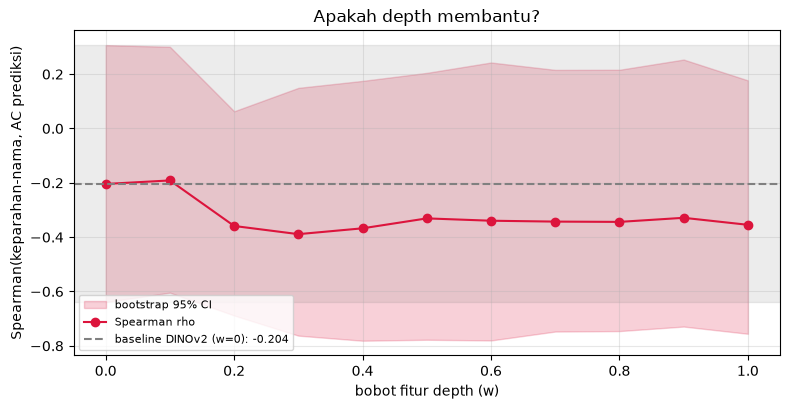

baseline w=0 : rho=-0.204  CI[-0.639, 0.307]
terbaik w=0.1: rho=-0.191  CI[-0.604, 0.301]
selisih      : +0.013

VERDIKT: CI tumpang tindih dengan baseline.
-> Perbaikan TIDAK signifikan. Dengan 18 foto, ini tidak bisa dibedakan dari kebetulan.
-> Jangan masukkan fitur depth ke pipeline atas dasar hasil ini.


In [15]:
base = SW.loc[SW.w == 0].iloc[0]
best = SW.loc[SW.rho.idxmax()]

plt.figure(figsize=(8,4.2))
plt.fill_between(SW.w, SW.lo, SW.hi, alpha=0.2, color="crimson", label="bootstrap 95% CI")
plt.plot(SW.w, SW.rho, "o-", color="crimson", label="Spearman rho")
plt.axhline(base.rho, ls="--", color="gray", label=f"baseline DINOv2 (w=0): {base.rho:.3f}")
plt.axhspan(base.lo, base.hi, color="gray", alpha=0.15)
plt.xlabel("bobot fitur depth (w)"); plt.ylabel("Spearman(keparahan-nama, AC prediksi)")
plt.title("Apakah depth membantu?"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gain = best.rho - base.rho
overlap = best.lo <= base.hi
print(f"baseline w=0 : rho={base.rho:.3f}  CI[{base.lo:.3f}, {base.hi:.3f}]")
print(f"terbaik w={best.w}: rho={best.rho:.3f}  CI[{best.lo:.3f}, {best.hi:.3f}]")
print(f"selisih      : {gain:+.3f}")
print()
if overlap:
    print("VERDIKT: CI tumpang tindih dengan baseline.")
    print("-> Perbaikan TIDAK signifikan. Dengan 18 foto, ini tidak bisa dibedakan dari kebetulan.")
    print("-> Jangan masukkan fitur depth ke pipeline atas dasar hasil ini.")
else:
    print("VERDIKT: CI terpisah dari baseline — sinyalnya nyata pada data ini.")
    print("-> Tetap perlu konfirmasi dgn label dokter sebelum dipakai serius.")

## 6. Ringkasan & apa yang dibawa ke dokter

Bagian ini menulis `depth_out2/summary2.json` dan mencetak ringkasan yang bisa langsung
dibaca saat diskusi.

Tiga hal yang layak ditanyakan ke drg. Laura, berdasarkan hasil notebook ini:

1. **Foto mana yang framing-nya tidak layak dinilai** — beberapa ROI mungkin memotong gigi atau
   sudutnya miring. Kalau ada standar pemotretan intraoral yang beliau pakai, itu jauh lebih
   berharga daripada perbaikan algoritma apa pun.
2. **Apakah 10 anchor AC yang kamu pakai versi resmi** — hasil pindai bisa berbeda kontras/crop
   dari kartu IOTN asli, dan seluruh pipeline bergantung padanya.
3. **Penilaian ganda dengan jeda** — minta beliau menilai 18 foto dua kali, terpisah waktu, untuk
   mendapatkan intra-rater reliability. Itu plafon performa modelmu.

In [16]:
summary2 = {
    "n_foto": int(len(FEAT)),
    "grid": CFG["grid"],
    "fitur_bersih": CLEAN,
    "fitur_dibuang": [f for f in DIRTY if f != "valid_frac"],
    "irregularity_dipakai": IRR_USE,
    "spekular_mean_pct": float(PROP["spec_pct"].mean()*100),
    "baseline_rho_w0": float(base.rho),
    "best_w": float(best.w),
    "best_rho": float(best.rho),
    "gain": float(best.rho - base.rho),
    "CI_overlap_dengan_baseline": bool(overlap),
    "kesimpulan": ("depth TIDAK terbukti membantu pada n=18" if overlap
                   else "depth tampak membantu, perlu konfirmasi label dokter"),
}
with open(os.path.join(CFG["out_dir"], "summary2.json"), "w") as f:
    json.dump(summary2, f, indent=2, ensure_ascii=False)
print(json.dumps(summary2, indent=2, ensure_ascii=False))

print("\nFile keluaran di", CFG["out_dir"] + "/:")
for f in sorted(os.listdir(CFG["out_dir"])):
    print("  -", f)

{
  "n_foto": 18,
  "grid": 384,
  "fitur_bersih": [
    "spread_iqr",
    "spread_std",
    "bimodality",
    "edge_density",
    "arch_std",
    "asim_LR",
    "asim_TB",
    "center_dev"
  ],
  "fitur_dibuang": [
    "rough_mean",
    "rough_p90",
    "arch_range",
    "arch_curvature"
  ],
  "irregularity_dipakai": [
    "spacing_cv",
    "prom_cv"
  ],
  "spekular_mean_pct": 19.20616863435901,
  "baseline_rho_w0": -0.20413757577740987,
  "best_w": 0.1,
  "best_rho": -0.1912446762546261,
  "gain": 0.012892899522783774,
  "CI_overlap_dengan_baseline": true,
  "kesimpulan": "depth TIDAK terbukti membantu pada n=18"
}

File keluaran di depth_out2/:
  - confound_matrix.csv
  - features_v2.csv
  - fusion_sweep.csv
  - irregularity.csv
  - summary2.json
